# NLP Project

# Import Libraries

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import joblib

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [99]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Visla\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Visla\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# Load Dataset

In [101]:
dataset=pd.read_csv("C:\\Users\\Visla\\Downloads\\Files\\Project_file\\Project-6\\Restaurant_Reviews.tsv",sep="\t")

In [102]:
dataset

,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1
...,...,...
995,I think food should have flavor and texture an...,0
996,Appetite instantly gone.,0
997,Overall I was not impressed and would not go b...,0
998,"The whole experience was underwhelming, and I ...",0


In [103]:
print(dataset['Liked'].head())

0    1
1    0
2    0
3    1
4    1
Name: Liked, dtype: int64


In [104]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  1000 non-null   object
 1   Liked   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB
None


In [105]:
print(dataset.shape)

print(dataset.isnull().sum())

(1000, 2)
Review    0
Liked     0
dtype: int64


In [106]:
dataset.describe() # Basic Statistics

,Liked
count,1000.00000
mean,0.50000
std,0.50025
min,0.00000
25%,0.00000
50%,0.50000
75%,1.00000
max,1.00000


In [109]:
print(dataset["Liked"].unique())
print(dataset["Liked"].isnull().sum())

[1 0]
0


# Sentiment Count

Liked
1    500
0    500
Name: count, dtype: int64


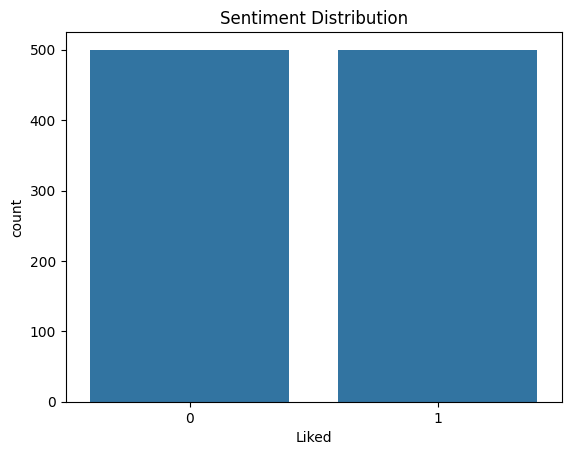

In [110]:
print(dataset['Liked'].value_counts())

sns.countplot(x='Liked', data=dataset)
plt.title("Sentiment Distribution")
plt.show()

# Feature Engineering

In [111]:
print(dataset['Liked'].value_counts())

Liked
1    500
0    500
Name: count, dtype: int64


In [112]:
dataset['char_count']=dataset["Review"].apply(len) # it is count each letters in one review words

In [113]:
dataset['char_count']

0       24
1       18
2       41
3       87
4       59
      ... 
995     66
996     24
997     50
998     91
999    134
Name: char_count, Length: 1000, dtype: int64

In [114]:

dataset['sent_count'] = dataset['Review'].apply(lambda x: len(nltk.sent_tokenize(x)))



In [115]:
dataset['sent_count']

0      2
1      1
2      1
3      1
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: sent_count, Length: 1000, dtype: int64

In [116]:
dataset['word_count']=dataset["Review"].apply(lambda x:len(str(x).split())) # count just words in the review

In [117]:
dataset['word_count']

0       4
1       4
2       8
3      15
4      12
       ..
995    12
996     3
997    10
998    16
999    28
Name: word_count, Length: 1000, dtype: int64

In [118]:
dataset

,Review,Liked,char_count,sent_count,word_count
0,Wow... Loved this place.,1,24,2,4
1,Crust is not good.,0,18,1,4
2,Not tasty and the texture was just nasty.,0,41,1,8
3,Stopped by during the late May bank holiday of...,1,87,1,15
4,The selection on the menu was great and so wer...,1,59,1,12
...,...,...,...,...,...
995,I think food should have flavor and texture an...,0,66,1,12
996,Appetite instantly gone.,0,24,1,3
997,Overall I was not impressed and would not go b...,0,50,1,10
998,"The whole experience was underwhelming, and I ...",0,91,1,16


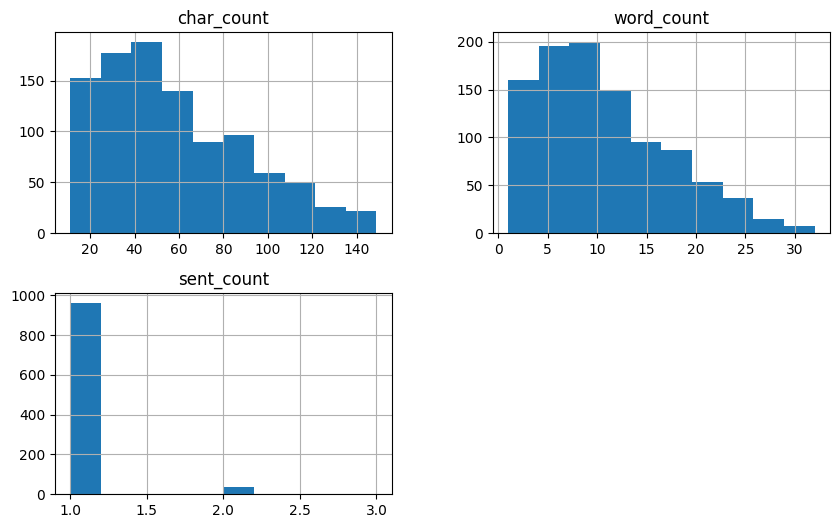

In [119]:
dataset[['char_count','word_count','sent_count']].hist(figsize=(10,6))
plt.show()

In [120]:
import nltk

In [121]:
dataset

,Review,Liked,char_count,sent_count,word_count
0,Wow... Loved this place.,1,24,2,4
1,Crust is not good.,0,18,1,4
2,Not tasty and the texture was just nasty.,0,41,1,8
3,Stopped by during the late May bank holiday of...,1,87,1,15
4,The selection on the menu was great and so wer...,1,59,1,12
...,...,...,...,...,...
995,I think food should have flavor and texture an...,0,66,1,12
996,Appetite instantly gone.,0,24,1,3
997,Overall I was not impressed and would not go b...,0,50,1,10
998,"The whole experience was underwhelming, and I ...",0,91,1,16


In [122]:
dataset[dataset['Liked']==1]['char_count'].mean() # positive review==1 of char_count

np.float64(55.88)

In [123]:
dataset[dataset['Liked']==0]['char_count'].mean() # negative review==0  of char_count

np.float64(60.75)

In [124]:
import re

In [125]:
dataset['Review'][0]

'Wow... Loved this place.'

In [126]:
dataset['Review'][999]

"Then, as if I hadn't wasted enough of my life there, they poured salt in the wound by drawing out the time it took to bring the check."

In [127]:
dataset['Review'][111]

"At least 40min passed in between us ordering and the food arriving, and it wasn't that busy."

# dataset['Review'][0]) first review is checking 

In [128]:
review=re.sub('[^a-zA-Z]',' ',dataset['Review'][0]) # why because this remove this comma 
# 'Wow... Loved this place.'


In [129]:
review

'Wow    Loved this place '

In [130]:
review=review.lower() # dataset['Review'][0])

In [131]:
review

'wow    loved this place '

In [132]:
review=review.split() # dataset['Review'][0])

In [133]:
review

['wow', 'loved', 'this', 'place']

In [134]:
from nltk.corpus import stopwords

In [135]:
all_stopwords=stopwords.words("english")

In [136]:
all_stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [137]:
review=[word for word in review if word not in set(all_stopwords)] # dataset['Review'][0])

In [138]:
review

['wow', 'loved', 'place']

# dataset['Review'][1]) two review is checking

In [139]:
review=re.sub('[^a-zA-Z]',' ',dataset['Review'][1]) # why because this remove any like that commas 

In [140]:
review

'Crust is not good '

In [141]:
review=review.lower() # dataset['Review'][1])

In [142]:
review

'crust is not good '

In [143]:
review=review.split() # dataset['Review'][1])

In [144]:
review

['crust', 'is', 'not', 'good']

In [145]:
all_stopwords=stopwords.words("english")


In [146]:
all_stopwords.remove("not")

In [147]:
all_stopwords

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'only',
 'o

In [148]:
review=[word for word in review if word not in set(all_stopwords)] # dataset['Review'][1])

In [149]:
review

['crust', 'not', 'good']

In [150]:
from nltk.stem import PorterStemmer

In [151]:
ps=PorterStemmer()

In [152]:
review=[ps.stem(word) for word in review]

In [153]:
review=" ".join(review)

In [154]:
review

'crust not good'

In [155]:
import re
custom_stopwords = {'don', "don't", 'ain', 'aren', "aren't", 'couldn', "couldn't",
                    'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't",
                    'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't",
                    'needn', "needn't", 'shan', "shan't", 'no', 'nor', 'not', 'shouldn', "shouldn't",
                    'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"}



In [162]:
corpus = []
ps = PorterStemmer()

stop_words = set(stopwords.words("english")) - custom_stopwords

for i in range(len(dataset)):
    review = re.sub('[^a-zA-Z]', ' ', dataset['Review'][i])
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if word not in stop_words]
    review = " ".join(review)
    corpus.append(review)

print(corpus[:5])

['wow love place', 'crust not good', 'not tasti textur nasti', 'stop late may bank holiday rick steve recommend love', 'select menu great price']


In [163]:

dataset.head()

,Review,Liked,char_count,sent_count,word_count
0,Wow... Loved this place.,1,24,2,4
1,Crust is not good.,0,18,1,4
2,Not tasty and the texture was just nasty.,0,41,1,8
3,Stopped by during the late May bank holiday of...,1,87,1,15
4,The selection on the menu was great and so wer...,1,59,1,12


# Positive WordCloud

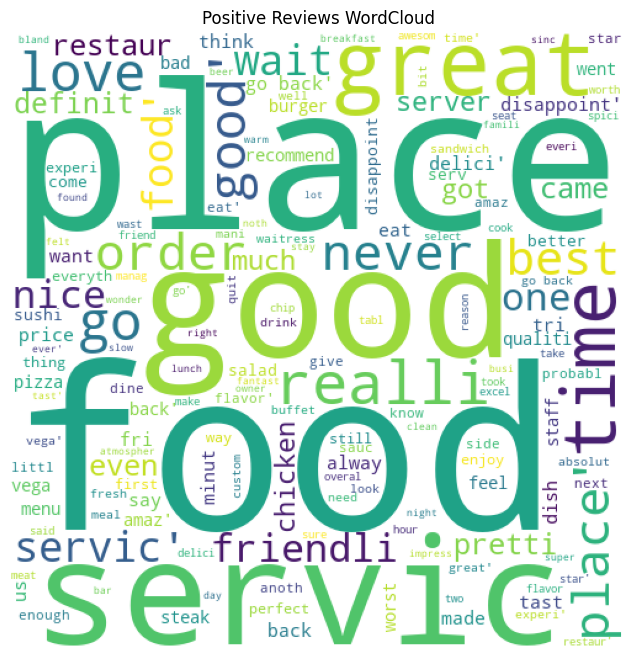

In [164]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_reviews = corpus[:]

wc = WordCloud(width=500,height=500,min_font_size=8,background_color="white")
positive_wc = wc.generate(str(positive_reviews))

plt.figure(figsize=(8,8))
plt.imshow(positive_wc)
plt.axis("off")
plt.title("Positive Reviews WordCloud")
plt.show()

# TF-IDF Vectorization

In [165]:
from sklearn.feature_extraction.text import TfidfVectorizer

cv = TfidfVectorizer(max_features=1500)

X = cv.fit_transform(corpus).toarray()

y = dataset["Liked"].values # This converts text into numbers.

# Train Test Split

In [166]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( # Splits data into training and testing.
    X, y, test_size=0.20, random_state=0
)

# Random Forest

# Train model

In [167]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier()
classifier.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Accuracy

In [169]:
y_pred = classifier.predict(X_test)

In [170]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred)*100)

Accuracy: 77.5


In [171]:
from sklearn.metrics import confusion_matrix # Confusion matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[94  3]
 [42 61]]


In [172]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.97      0.81        97
           1       0.95      0.59      0.73       103

    accuracy                           0.78       200
   macro avg       0.82      0.78      0.77       200
weighted avg       0.83      0.78      0.77       200



# Logistic Regression

In [173]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression()
classifier.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [174]:
cv = TfidfVectorizer(max_features=3000, ngram_range=(1,2))

X = cv.fit_transform(corpus).toarray()
y = dataset["Liked"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

classifier = LogisticRegression()
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred)*100)
print(confusion_matrix(y_test, y_pred))

Accuracy: 82.5
[[82 18]
 [17 83]]


# Naive Baye

In [175]:
from sklearn.naive_bayes import GaussianNB

classifier = GaussianNB()
classifier.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [176]:
cv = TfidfVectorizer(max_features=3000, ngram_range=(1,2))

X = cv.fit_transform(corpus).toarray()
y = dataset["Liked"].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

classifier = GaussianNB()
classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred)*100)
print(confusion_matrix(y_test, y_pred))

Accuracy: 69.5
[[62 38]
 [23 77]]


In [177]:
import joblib

joblib.dump(classifier, "best_sentiment_model.pkl")
joblib.dump(cv, "vectorizer.pkl")

['vectorizer.pkl']

# comparison

In [178]:
import pandas as pd

# Model comparison results
results_df = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression", "Random Forest"],
    "Accuracy": [0.70, 0.85, 0.80]
})



In [179]:
# Display dataframe
results_df

,Model,Accuracy
0,Naive Bayes,0.70
1,Logistic Regression,0.85
2,Random Forest,0.80


# Test your own review

In [180]:
sample = ["The food was very tasty and service was excellent"]

sample = re.sub('[^a-zA-Z]', ' ', sample[0])
sample = sample.lower()
sample = sample.split()
sample = [ps.stem(word) for word in sample if word not in stop_words]
sample = " ".join(sample)

sample = cv.transform([sample]).toarray()

prediction = classifier.predict(sample)

if prediction[0] == 1:
    print("Positive Review ")
else:
    print("Negative Review ")

Positive Review 


# demo

In [ ]:
while True:
    sample_review = input("Enter your review (or type 'exit' to stop): ")

    if sample_review.lower() == "exit":
        print("Stopped prediction.")
        break

    # Preprocess
    review = re.sub('[^a-zA-Z]', ' ', sample_review)
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if word not in stop_words]
    review = " ".join(review)

    # Convert into TF-IDF
    review_vector = cv.transform([review]).toarray()

    # Predict
    prediction = classifier.predict(review_vector)

    # Output
    if prediction[0] == 1:
        print("Prediction: Positive Review \n")
    else:
        print("Prediction: Negative Review \n")

Prediction: Positive Review 

